In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import json
import matplotlib.pyplot as plt

In [97]:
base = "sc_base_math500.json"
intuit = "sc_int_math500.json"

prm = "genprm_base_rewards_math500.json"
prm_trained = "sc_int_prm_math500.json"

In [3]:
# with open(base, 'r') as data:
#     base_data = json.load(data)

# with open(intuit, 'r') as data:
#     int_data = json.load(data)

# with open(prm_int, 'r') as data:
#     prm_int_data = json.load(data)

In [98]:
df_base = pd.read_json(base)
df_int = pd.read_json(intuit)
df_prm = pd.read_json(prm)

df_prm_trained = pd.read_json(prm_trained)

In [99]:
# correct_base = df_base[df_base['metrics'] == {'extractive_match': 1.0}]
# incorrect_base = df_base[df_base['metrics'] != {'extractive_match': 1.0}]

# correct_base = df_base[df_base['metrics'] == {'math_pass@1:1_samples': 1.0}]
# incorrect_base = df_base[df_base['metrics'] != {'math_pass@1:1_samples': 1.0}]

# correct_int = df_int[df_int['metrics'] == {'extractive_match': 1.0}]
# incorrect_int = df_int[df_int['metrics'] != {'extractive_match': 1.0}]

correct_prm = df_prm[df_prm['metrics'] == "{'extractive_match': 1.0}"]
incorrect_prm = df_prm[df_prm['metrics'] != "{'extractive_match': 1.0}"]


df_base['correct'] = [df_base.iloc[i]['metrics']['math_pass@1:1_samples'] for i in range(len(df_base))]
correct_base = df_base[df_base['correct'] == 1]
incorrect_base = df_base[df_base['correct'] != 1]

df_int['correct'] = [df_int.iloc[i]['metrics']['math_pass@1:1_samples'] for i in range(len(df_int))]
correct_int = df_int[df_int['correct'] == 1]
incorrect_int = df_int[df_int['correct'] != 1]

df_prm['correct'] = [df_prm.iloc[i]['metrics']['math_pass@1:1_samples'] for i in range(len(df_prm))]
correct_prm = df_prm[df_prm['correct'] == 1]
incorrect_prm = df_prm[df_prm['correct'] != 1]

df_prm_trained['correct'] = [df_prm_trained.iloc[i]['metrics']['math_pass@1:1_samples'] for i in range(len(df_prm_trained))]
correct_prm_int = df_prm_trained[df_prm_trained['correct'] == 1]
incorrect_prm_int = df_prm_trained[df_prm_trained['correct'] != 1]

correct_base_sc = correct_base['confidence_list'].map(lambda x: x[0])
incorrect_base_sc = incorrect_base['confidence_list'].map(lambda x: x[0])

correct_int_sc = correct_int['confidence_list'].map(lambda x: x[0])
incorrect_int_sc = incorrect_int['confidence_list'].map(lambda x: x[0])

correct_prm_int_sc = correct_prm_int['confidence_list'].map(lambda x: x[0])
incorrect_prm_int_sc = incorrect_prm_int['confidence_list'].map(lambda x: x[0])

correct_base_prm = correct_prm['process_reward']
incorrect_base_prm = incorrect_prm['process_reward']

## save as csv file for plotting with pgfplots


In [100]:
correct_base_sc.to_csv('correct_base.csv')
incorrect_base_sc.to_csv('incorrect_base.csv')
correct_int_sc.to_csv('correct_int.csv')
incorrect_int_sc.to_csv('incorrect_int.csv')
correct_prm_int_sc.to_csv('correct_prm_int.csv')
incorrect_prm_int_sc.to_csv('incorrect_prm_int.csv')

correct_base_prm.to_csv('correct_base_prm.csv')
incorrect_base_prm.to_csv('incorrect_base_prm.csv')

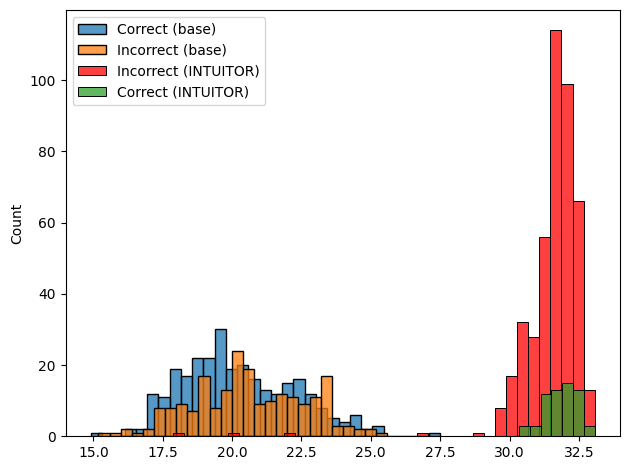

In [103]:
sns.histplot(list(map(lambda x: x[0], correct_base['confidence_list'])), label='Correct (base)', binwidth=0.4)
sns.histplot(list(map(lambda x: x[0], incorrect_base['confidence_list'])), label='Incorrect (base)', binwidth=0.4)

sns.histplot(list(map(lambda x: x[0], incorrect_int['confidence_list'])), color='red', label='Incorrect (INTUITOR)', binwidth=0.4)
sns.histplot(list(map(lambda x: x[0], correct_int['confidence_list'])), label='Correct (INTUITOR)', binwidth=0.4)

plt.legend()
plt.tight_layout()


<Axes: ylabel='Count'>

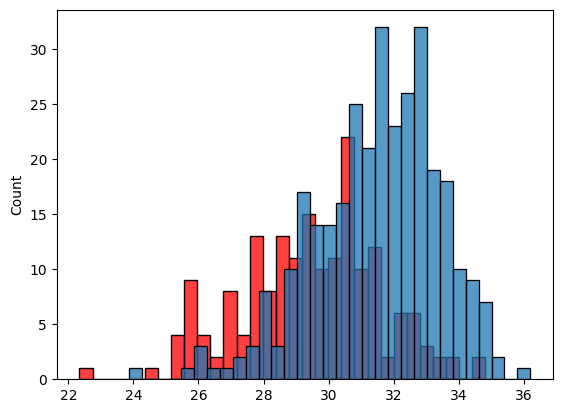

In [104]:
sns.histplot(list(map(lambda x: x[0], incorrect_prm_int['confidence_list'])), color='red', label='Incorrect (PRM + INT)', binwidth=0.4)
sns.histplot(list(map(lambda x: x[0], correct_prm_int['confidence_list'])), label='Correct (PRM + INT)', binwidth=0.4)

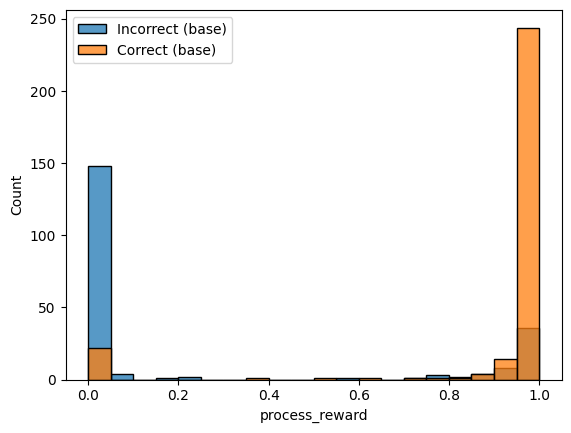

In [31]:
# sns.kdeplot(incorrect_prm['process_reward'], label='Incorrect (base)')
# sns.kdeplot(correct_prm['process_reward'] , label='Correct (base)')
sns.histplot(incorrect_prm['process_reward'], label='Incorrect (base)', binwidth=0.05)
sns.histplot(correct_prm['process_reward'] , label='Correct (base)', binwidth=0.05)
plt.legend()

In [44]:
import hvplot.pandas

In [67]:
p1 = correct_base_sc.hvplot.hist(normed=True, label='Correct (base)', alpha=0.4)*correct_base_sc.hvplot.kde()
p2 = incorrect_base_sc.hvplot.hist(normed=True, label='Incorrect (base)', alpha=0.4)*incorrect_base_sc.hvplot.kde()

p3 = correct_int_sc.hvplot.hist(normed=True, label='Correct (INTUITOR)', alpha=0.4)*correct_int_sc.hvplot.kde()
p4 = incorrect_int_sc.hvplot.hist(normed=True, label='Incorrect (INTUITOR)', alpha=0.4)*incorrect_int_sc.hvplot.kde()

combined_plot = p1 * p2 * p3 * p4

In [72]:
combined_plot.opts(
                    show_legend=True,
                    xlabel='Self-Certainty',
                    ylabel='Density'  # you can also change ylabel
                )

:Overlay
   .Histogram.I      :Histogram   [confidence_list]   (Frequency)
   .Distribution.I   :Distribution   [confidence_list]   (Density)
   .Histogram.II     :Histogram   [confidence_list]   (Frequency)
   .Distribution.II  :Distribution   [confidence_list]   (Density)
   .Histogram.III    :Histogram   [confidence_list]   (Frequency)
   .Distribution.III :Distribution   [confidence_list]   (Density)
   .Histogram.IV     :Histogram   [confidence_list]   (Frequency)
   .Distribution.IV  :Distribution   [confidence_list]   (Density)

In [88]:
from pingouin import mwu

In [107]:
mws_sc_base = mwu(correct_base_sc.to_list(), incorrect_base_sc.to_list())
mws_sc_int = mwu(correct_int_sc.to_list(), incorrect_int_sc.to_list())
mws_prm = mwu(correct_base_prm.to_list(), incorrect_base_prm.to_list())
mws_prm_int = mwu(correct_prm_int_sc.to_list(), incorrect_prm_int_sc.to_list())

In [94]:
mws_sc_base

,U-val,alternative,p-val,RBC,CLES
MWU,26697.0,two-sided,0.018606,-0.123251,0.438374


In [95]:
mws_sc_int

,U-val,alternative,p-val,RBC,CLES
MWU,15972.0,two-sided,0.024584,0.176315,0.588157


In [96]:
mws_prm

,U-val,alternative,p-val,RBC,CLES
MWU,54058.0,two-sided,1.355566e-49,0.775304,0.887652


In [108]:
mws_prm_int

,U-val,alternative,p-val,RBC,CLES
MWU,44354.0,two-sided,2.003478e-23,0.536362,0.768181


In [120]:
correct_int_sc.hvplot.hist()

:Histogram   [confidence_list]   (Count)

In [126]:
incorrect_base_prm.mean()

np.float64(0.25203776860666666)